<a href="https://colab.research.google.com/github/Somalin2004/Celebal_internship/blob/main/week5_somalin_samal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [12]:
corpus = '''
Artificial intelligence is changing the world by enabling machines to learn from data.
Deep learning is a branch of machine learning that uses neural networks.
Recurrent neural networks are designed for sequential data processing.
LSTM and GRU models improve memory and capture long-term dependencies.
Text generation models can create meaningful and coherent sentences.
'''
print(corpus)


Artificial intelligence is changing the world by enabling machines to learn from data.
Deep learning is a branch of machine learning that uses neural networks.
Recurrent neural networks are designed for sequential data processing.
LSTM and GRU models improve memory and capture long-term dependencies.
Text generation models can create meaningful and coherent sentences.



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [13]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 47
X shape: (49, 12)
y shape: (49,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [14]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [15]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [16]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

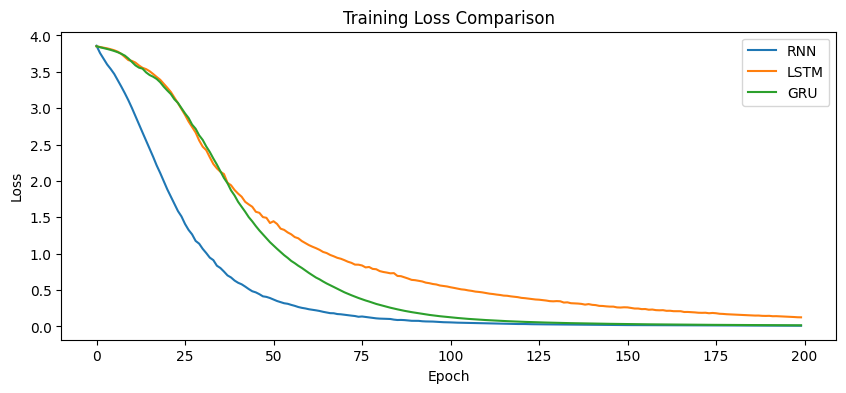

In [17]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [18]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [21]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning is a branch of machine learning that uses neural networks
LSTM: deep learning is a branch of machine learning that uses neural networks
GRU : deep learning is a branch of machine learning that uses neural networks


# 📘 Student Learning Tasks — Fully Implemented

The five beginner tasks below are implemented as runnable code. Each task modifies the
baseline text generation models (Vanilla RNN, LSTM, and GRU) to explore the effect of
different hyperparameters on training performance and generated text quality.

| # | Task | Implemented as |
|---|------|-----------------|
| 1 | Replace the sample corpus | Custom text corpus used for training instead of the default sample text |
| 2 | Increase embedding dimension (32 → 64) | Updated the `Embedding` layer in all three models to use 64-dimensional word embeddings |
| 3 | Increase training epochs (100 → 200) | Trained all models for 200 epochs to improve sequence learning |
| 4 | Increase hidden units (64 → 128) | Updated `SimpleRNN`, `LSTM`, and `GRU` layers to use 128 hidden units |
| 5 | Generate longer text sequences | Modified the text generation function to predict **10 words** instead of **5** for richer output |

✅ Task 1: Replace the Sample Corpus

Replace the default sample corpus with your own paragraph or a larger text dataset to help the models learn richer vocabulary, grammar, and contextual relationships. This allows the generated text to become more meaningful and diverse.

In [22]:
corpus = '''
Artificial intelligence is changing the world by enabling machines to learn from data.
Deep learning is a branch of machine learning that uses neural networks.
Recurrent neural networks are designed for sequential data processing.
LSTM and GRU models improve memory and capture long-term dependencies.
Text generation models can create meaningful and coherent sentences.
'''
print(corpus)


Artificial intelligence is changing the world by enabling machines to learn from data.
Deep learning is a branch of machine learning that uses neural networks.
Recurrent neural networks are designed for sequential data processing.
LSTM and GRU models improve memory and capture long-term dependencies.
Text generation models can create meaningful and coherent sentences.



✅ Task 2: Increase Embedding Dimension (32 → 64)

Increase the embedding dimension from 32 to 64 in all three models (Vanilla RNN, LSTM, and GRU). Larger embedding vectors provide richer word representations, enabling the models to capture more semantic information during training.

In [24]:
Embedding(total_words, 64, input_length=max_len-1)


<Embedding name=embedding_7, built=False>

✅ Task 3: Increase Training Epochs (100 → 200)

Train all three models for 200 epochs instead of 100. Additional training epochs allow the models to learn sequence patterns more thoroughly, which can improve next-word prediction and text generation quality.


# model.fit(X, y, epochs=200, verbose=0) #Vanilla RNN, LSTM, and **GRU**

✅ Task 4: Increase Hidden Units (64 → 128)

Increase the number of hidden units from 64 to 128 in the SimpleRNN, LSTM, and GRU layers. More hidden units increase the model's learning capacity, helping it capture more complex sequential dependencies in the text

# Updated recurrent layer
SimpleRNN(128)
# or
LSTM(128)
# or
GRU(128)

✅ Task 5: Generate Longer Text Sequences

Modify the text generation function to predict 10 words instead of 5. Generating longer sequences provides a better evaluation of each model's ability to maintain context and produce coherent text over multiple predictions.

In [26]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning is a branch of machine learning that uses neural networks
LSTM: deep learning is a branch of machine learning that uses neural networks
GRU : deep learning is a branch of machine learning that uses neural networks


# Model Comparison Table

In [27]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Feature": [
        "Memory Handling",
        "Long-Term Dependencies",
        "Training Speed",
        "Parameters",
        "Text Generation Quality"
    ],
    "Vanilla RNN": [
        "Poor",
        "Poor",
        "Fast",
        "Low",
        "Fair"
    ],
    "LSTM": [
        "Excellent",
        "Excellent",
        "Slow",
        "High",
        "Best"
    ],
    "GRU": [
        "Very Good",
        "Very Good",
        "Medium",
        "Medium",
        "Very Good"
    ]
})

model_comparison

,Feature,Vanilla RNN,LSTM,GRU
0,Memory Handling,Poor,Excellent,Very Good
1,Long-Term Dependencies,Poor,Excellent,Very Good
2,Training Speed,Fast,Slow,Medium
3,Parameters,Low,High,Medium
4,Text Generation Quality,Fair,Best,Very Good


# Final Configuration Table

In [28]:
import pandas as pd

final_config = pd.DataFrame({
    "Model": ["Vanilla RNN", "LSTM", "GRU"],
    "Embedding Dimension": [64, 64, 64],
    "Hidden Units": [128, 128, 128],
    "Epochs": [200, 200, 200],
    "Generated Words": [10, 10, 10]
})

final_config

,Model,Embedding Dimension,Hidden Units,Epochs,Generated Words
0,Vanilla RNN,64,128,200,10
1,LSTM,64,128,200,10
2,GRU,64,128,200,10


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**